In [32]:
import os
import re
import gc

import math
import numpy as np
from numpy.random import randint, normal, uniform
import pylab as pl
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

from functools import partial
from joblib import Parallel, delayed
import multiprocessing

from astropy import units as u

import healpy as hp
import camb

from ksw import Cosmology, Data, ReducedBispectrum, KSW, Shape
from ksw.radial_functional import radial_func

import h5py
from multiprocessing import cpu_count
from tqdm.auto import tqdm
from tqdm.contrib.concurrent import process_map

from pixell import enmap, reproject, utils, lensing, curvedsky

import concurrent.futures as cf
import time
from concurrent.futures import ProcessPoolExecutor
from itertools import product

%matplotlib inline

In [ ]:
import time
from psutil import Process
from threading import Thread


class MemoryMonitor(Thread):
    """Monitor the memory usage in MB in a separate thread.

    Note that this class is good enough to highlight the memory profile of
    Parallel in this example, but is not a general purpose profiler fit for
    all cases.
    """
    def __init__(self):
        super().__init__()
        self.stop = False
        self.memory_buffer = []
        self.start()

    def get_memory(self):
        "Get memory of a process and its children."
        p = Process()
        memory = p.memory_info().rss
        for c in p.children():
            memory += c.memory_info().rss
        return memory

    def run(self):
        memory_start = self.get_memory()
        while not self.stop:
            self.memory_buffer.append(self.get_memory() - memory_start)
            time.sleep(0.2)

    def join(self):
        self.stop = True
        super().join()

# Data Generator

This code primamrly uses [KSW](https://github.com/AdriJD/ksw/tree/master/src), as a means to generate non-gaussian cmb maps. These get stored in a data file with the fnls, fullsky maps, and patches.

The fullsky maps are generated using the method discussed in [CMB lensing and primordial non-Gaussianity](https://arxiv.org/abs/0905.4732), where we find (eq. 6) 
$$
a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}{^{NG}}
$$
and generated the full sky map by passing these $a_{\ell m}$ into healpy.

Most of this code is to calculate the term (eq. 27)

$$
a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]
$$

and

$$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$$

$$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$$

$$
B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}
$$

where $\Delta_\phi$ is pridormial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions

---

## Settings

See: https://camb.readthedocs.io/en/latest/model.html

Some values are forced during init of ksw.Cosmology. 
For an example on how to modify these values after init: https://github.com/AdriJD/ksw/blob/fba3250cfe4c5145b5db12fa54bbc54bbcf5a56c/tests/python/test_cosmology.py#L65

In [33]:
cosmo_params = {
    'H0': 67.5,
    'r': 0,
    'As': 2.13e-09,
    'ns': 0.9624,
    'pivot_scalar': 0.05,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'mnu': 0.06,
    'tau': 0.0561,
    'TCMB': 2.7255,
    'max_l': 3000,

    'lmax': 2000,
    'lens_potential_accuracy': 4,


    ## These are forced by ksw
    "DoLateRadTruncation": False,
    "AccuracyBoost":2.,
    # "BessIntBoost": 30.,
    # "KmaxBoost": 3.,
    # "IntTolBoost": 4.,
    # "TimeStepBoost": 4.,
    # "SourcekAccuracyBoost": 5.,
    # "BesselBoost": 5.,
    # "IntkAccuracyBoost": 5.,
    "lSampleBoost": 2.,
    "lAccuracyBoost": 2.,
    # "AccurateBB": True,
}
lmax=cosmo_params['lmax']

camb_params_obj = camb.set_params(**cosmo_params)
print(camb_params_obj)

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_lens
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 3000
 max_l_tensor = 600
 max_eta_k = 72000.0
 max_eta_k_tensor = 1200.0
 ombh2 = 0.02233
 omch2 = 0.1198
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 67.5
 TCMB = 2.7255
 YHe = 0.2458384128277519
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <InitialPowerLaw>
   tensor_parameterization = tensor_param_rpivot
   ns = 0.9624
   nr

lmax >= 300 is enforced by the ksw code due to errors with CAMB. 
lmax needs to be somewhat smaller then max_l, if you get errors about c_ell change these.

You will get warning messages if lmax > 4\* nside.  

nside should be of type 2\*\*n

num_patches should be even.

patch_side_deg \* num_patches \<\= 180, patch_side_deg \<\= 45; or you will overlap patches 

r_max is given in Mpc, we preform r_res slices over this volume to do the integral. Values have been picked by guestimation, with r_res being set low to help test. Will want to raise this for better calculations.

KSW only supports polarization values of 'T', 'E', ['T', 'E'].

In [34]:
fnl_range=(-1000, 1000)

nsims = 20                   # currently nsims % save_size === 0
npatches = 10                # number of patches to generate per sim

nside=1024

patch_side_deg = 10

r_min = 1                    # Mpc, min radius for the patch     
r_max = 50000                # Mpc, max radius for the patch

# valid values 'T', 'E', ['T', 'E']
polarizations = ['T'] #, 'E']

noise_loc = 0

# Table 1 from smith and zald, planck levels
# nu is 100, 143, 217
# we will used 143 as the base for single value
beam_width = 7.1 * u.arcmin #*10**-12
noise_scale = 43 * u.arcmin #*10**-12# in uK * arcmin

# Just helps control memory for the alm_ng calculations
batch_size = 100

do_lensing = True

save_fullsky = True

force_alm_gen = False 

# For easy switching between notebook and slurm, just disables plots
debug = True


In [35]:
#Settings that are calculated based on others

npol = 1 if isinstance(polarizations, str) else len(polarizations)
pol_b = False #npol > 1 # TODO fix

nell = lmax + 1
nelem = hp.Alm.getsize(lmax)
npix = hp.nside2npix(nside)
ells = np.arange(nell)

pix_size = patch_side_deg*60 / nside

alm_ls, alm_ms = hp.Alm.getlm(lmax)

if isinstance(polarizations, str):
    chars_of_polarizations = polarizations
elif isinstance(polarizations, list):
    chars_of_polarizations = ''.join(polarizations)
else:
    raise TypeError("polarizations must be either a string or a list of strings")

We set the file name best on settings, this will let us load in the data better and ensure we know what settings we are dealing with

In [36]:
base_name = f'{nside}_{chars_of_polarizations}_{nsims}x{npatches}_fnl{fnl_range[0]}-{fnl_range[1]}'

base_dir = 'data/ksw'
data_dir = base_dir + ('/lensed' if lensing else '/unlensed')

print(f'running sims for {data_dir}/{base_name}')

running sims for data/ksw/lensed/1024_T_20x10_fnl-1000-1000


In [37]:
if not os.path.exists(data_dir): 
    os.makedirs(data_dir)
    print(f'Created directory {data_dir}')
else:
    print(f'Reusing directory {data_dir}')

Reusing directory data/ksw/lensed


In [38]:
def load_data(data_file, key):
    print('Loading data',key,'from',data_file)
    with h5py.File(data_file, 'r') as hdf:
        return hdf.get(key)[()]

data_filename = f'{base_name}.hdf5'
data_file = os.path.join(data_dir, data_filename)

if save_fullsky:
    fs_filename = f'{base_name}.fullsky.hdf5'
    fs_file = os.path.join(data_dir, fs_filename)

alm_cache_dir = f'{base_dir}/alm_cache'
if not os.path.exists(alm_cache_dir): 
    os.makedirs(alm_cache_dir)
    print(f'Created cache directory {alm_cache_dir}')

alm_filename = f'{base_name}.alms.hdf5'
alm_file = os.path.join(alm_cache_dir, alm_filename)

almng_filename = f'{base_name}.alms_ng.hdf5'
almng_file = os.path.join(alm_cache_dir, almng_filename)

In [39]:
# Check if we need to generate alms, load in alms if we can
atest = os.path.join(alm_cache_dir, f'{base_name}.alms.hdf5')
btest = os.path.join(alm_cache_dir, f'{base_name}.alms_ng.hdf5')          
if not force_alm_gen and os.path.isfile(atest) and os.path.isfile(btest):
    print('Found existing alms, using them')
    alms = load_data(atest, 'alm')
    almngs = load_data(btest, 'almng')
    gen_alms = False
    print('alms loaded', alms.shape)
    print('alm_ng loaded', almngs.shape)
else:
    print('Generating new alms')
    alms = None
    almngs = None
    gen_alms = True

Generating new alms


In [40]:
# Setup noise and beams, pol_B isn't working
# TODO: Figure out QU values for beam and specs for noise

noise_scales_rad = noise_scale.to_value(u.radian)
beam_widths_rad = beam_width.to_value(u.radian)

# Order for pol_b is TT,EE,TE
if pol_b: # TODO
    noise_ell = np.ones((3, nell))*noise_scales_rad[:, np.newaxis]**2

    # I don't think beampol is correct
    beam_ell = hp.gauss_beam(beam_widths_rad, lmax, True)
    beam_ell = beam_ell.swapaxes(0,1)[:npol]
else:
    noise_ell = np.ones((nell)) * noise_scales_rad**2
    beam_ell = hp.gauss_beam(beam_widths_rad, lmax, True)
    beam_ell = beam_ell.swapaxes(0,1)[:npol]

For the radii we follow Table 2. of Smith and Zaldarriaga which gives a greater density of points near reionization and recombination. 

Spacing for all ranges but the last row are linear, with the last row having log spacing.

radii are in Mpc

In [41]:
import numpy as np

radii = []
#          start,  stop, resolution
ranges = [(    0,  9500, 150), 
        ( 9500, 11000, 300), 
        (11000, 13800, 150), 
        (13800, 14600, 400), 
        (14600, 16000, 100), 
        (16000, 50000, 100)]

for r in ranges:
    start = max(r_min, r[0])
    end = min(r_max, r[1])

    if start > end:
        continue

    if r == ranges[-1]: # For the last range, use logspace
        temp_radii = np.logspace(np.log10(start), np.log10(end), num=r[2])
    else:
        temp_radii = np.linspace(start, end, num=r[2], endpoint=False)

    radii.extend(temp_radii)

radii = np.array([r for r in radii if r_min <= r < r_max])
drs = np.diff(radii)

In [42]:
if gen_alms or debug:
    cosmo = Cosmology(camb_params_obj, verbose=True)

    # Additional settings here, i.e.
    # cosmo._setattr_camb('ns', 0.9624, subclass='InitPower')

    cosmo.compute_transfer(cosmo_params['max_l'])
    cosmo.compute_c_ell()

    data = Data(lmax, noise_ell, beam_ell, polarizations, cosmo)

    c_ells = data.cosmology.c_ell['unlensed_scalar']

    tr_ell_k = data.cosmology.transfer['tr_ell_k']
    tr_ells = data.cosmology.transfer['ells']
    tr_k = data.cosmology.transfer['k']

    mask = (tr_ells <= lmax)
    tr_ell_k = tr_ell_k[mask]
    tr_ells = tr_ells[mask]

Updated CAMB param: BessIntBoost from 1.0 to 30.
Updated CAMB param: KmaxBoost from 1.0 to 3.
Updated CAMB param: IntTolBoost from 1.0 to 4.
Updated CAMB param: TimeStepBoost from 1.0 to 4.
Updated CAMB param: SourcekAccuracyBoost from 1.0 to 5.
Updated CAMB param: BesselBoost from 1.0 to 5.
Updated CAMB param: IntkAccuracyBoost from 1.0 to 5.
Updated CAMB param: AccurateBB from False to True.


`radial_func` computes $f_\ell^X(r) = \frac{2}{\pi} \int k^2 dk f(k) \Delta^{TX}_\ell(k) j_\ell(k r)$, we will use this to find 
$
\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)
$,
and
$
\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)
$. 

$\Delta_\ell^T(k)$, the transfer functions, are calculated sparsely (in l) by CAMB; We thus need to interpolate over the missing values to get `alpha_l`, `beta_l` which are suitable for the calculations. 

We do this with `CubicSpline`, but this could be changed if needed. 

We also go ahead and calculate `bl_div_cl`=$\beta_\ell / C_\ell$, which is used to calculate $B(r,\hat{n})$.

In [43]:
if gen_alms:
    def interpolate_ells(func, ells_sparse, ls, axis=1):
        return CubicSpline(ells_sparse, func, axis)(ls)

    delta_phi = (2 * np.pi) * cosmo_params['As'] * np.sqrt(3 / 5)

    f_k = np.ones((len(tr_k), 2), dtype=float)
    # f_k[:, 0] = 1                           # f_k for alpha
    f_k[:, 1] = tr_k**-3 * delta_phi          # f_k for beta

    rad = radial_func(f_k, tr_ell_k, tr_k, radii, tr_ells)

    alpha_ell = rad[:,:,:,0]
    alpha_l = np.concatenate(np.array([interpolate_ells(alpha_ell, tr_ells, ells)]))
    alpha_l = np.ascontiguousarray(alpha_l)

    beta_ell = rad[:,:,:,1]
    c_ells_new = c_ells['c_ell'][tr_ells, :npol]
    div = beta_ell / c_ells_new[np.newaxis, :, :]

    bl_div_cl = np.concatenate(np.array([interpolate_ells(div, tr_ells, ells)]))
    bl_div_cl = np.ascontiguousarray(bl_div_cl)

In [44]:
if gen_alms:
    # Each alm takes ~30Mb, TODO: Support splitting 
    alms = np.array([data.compute_alm_sim(False) for _ in tqdm(range(nsims), desc='a_lm progress')])
    print(alms.shape)

a_lm progress:   0%|          | 0/20 [00:00<?, ?it/s]

(20, 1, 2003001)


In [46]:
def get_alm(alm, bl_div_cl, alpha_l, r, dr):
    Balm = hp.almxfl(alm, bl_div_cl)
    B = hp.alm2map(Balm, nside=nside, lmax=lmax, pol=False)
    inner = hp.map2alm(B**2, lmax=lmax, pol=False, use_pixel_weights=True)
    kernel = hp.almxfl(inner, alpha_l)
    return dr * r**2 * kernel

if gen_alms:
    # We still hold all almngs in memory, but this should be about 30Mb per sim for 1024
    almngs = np.zeros((nsims, npol, nelem), dtype=complex)

    with Parallel(-1, verbose=0, temp_folder='data/tmp') as parallel:
        n_batches = math.ceil(len(radii) / batch_size)
        for i, pol in tqdm(product(range(nsims), range(npol)), total=nsims*npol, desc='total non-gaussian alm'):
            for batch_num in tqdm(range(n_batches), total=n_batches, desc=f'Batch {i} progress'):
                start_index = batch_num * batch_size
                end_index = min((batch_num + 1) * batch_size, len(radii))
                
                batch_radii = radii[start_index:end_index]
                batch_drs = drs[start_index:end_index]
                
                alms_batch = parallel(
                    delayed(get_alm)(alms[i, pol], bl_div_cl[ri, :, pol], alpha_l[ri, :, pol], batch_radii[ri], batch_drs[ri]) 
                    for ri in range(len(batch_radii)-1)
                )
                almngs[i, pol] += np.sum(alms_batch, axis=0)

            del alms_batch
            gc.collect()


total non-gaussian alm:   0%|          | 0/20 [00:00<?, ?it/s]

Batch 0 progress:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 1 progress:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 2 progress:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 3 progress:   0%|          | 0/12 [00:00<?, ?it/s]

...

Batch 6 progress:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 7 progress:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 8 progress:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 9 progress:   0%|          | 0/12 [00:00<?, ?it/s]

Batch 10 progress:   0%|          | 0/12 [00:00<?, ?it/s]

In [ ]:
def save_data(file_path, data_dict):
    compression_opts = dict()  # Compression options
    compression_opts['compression'] = 'gzip'  # Use gzip compression
    compression_opts['compression_opts'] = 9  # Maximum compression level

    print(f'Saving {file_path}...', end=' ')
    with h5py.File(file_path, 'w') as hf:  # Open the file in append mode
        for key, value in data_dict.items():
            if key in hf:
                # Resize the dataset to accommodate the new data
                hf[key].resize((hf[key].shape[0] + value.shape[0],) + value.shape[1:])
                # Append the new data
                hf[key][-value.shape[0]:] = value
            else:
                # Create a new dataset for this key with compression options
                hf.create_dataset(key, data=value, maxshape=(None,) + value.shape[1:], **compression_opts)
    print('Done!')

In [ ]:
if gen_alms:
    save_data(alm_file, {'alm': alms})
    save_data(almng_file, {'almng': almngs})

Saving data/ksw/alm_cache/1024_T_1x10_fnl-1000-1000.alms.hdf5... Done!
Saving data/ksw/alm_cache/1024_T_1x10_fnl-1000-1000.alms_ng.hdf5... Done!


In [ ]:
# Could possibly use band_geometry, since we will only need dec: +/- patch_side_deg
# Would this do anything noticable?
res = np.deg2rad(patch_side_deg / nside) # TODO Look into better value for res
fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
fs_map = enmap.empty(fs_shape, fs_wcs)

patch_maps = []
ps_rad = np.deg2rad(patch_side_deg)
for counter in np.arange(npatches//2):
    # [[dec_min,ra_min],[dec_max,ra_max]]
    top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
    t_geo = enmap.geometry(pos=top, res=res, proj="car")
    patch_maps.append(t_geo)

    bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
    b_geo = enmap.geometry(pos=bottom, res=res, proj="car")
    patch_maps.append(b_geo)

In [ ]:
def cutSqPatches_pixell(do_lensing, shape, wcs, fs_map, alms):
    car_map = curvedsky.alm2map(alms, fs_map)

    if do_lensing:
        phi_map = enmap.rand_gauss_harm(shape, wcs)*2*10**-10
        grad_phi = enmap.grad(phi_map)
        car_map = lensing.lens_map(car_map, grad_phi)

    patches = []
    for i in range(npatches):
        pshape, pwcs = patch_maps[i]
        patch = car_map.project(pshape, pwcs)
        patches.append(patch)
        
    return car_map, np.array(patches)

cutPatches = partial(cutSqPatches_pixell, do_lensing, fs_shape, fs_wcs, fs_map)

def run_sim(alm, alm_ng):    
    fnl = uniform(fnl_range[0], fnl_range[1])
    alm_prime = alm + fnl * alm_ng
    fsmap, patches = cutPatches(alm_prime)
    return fnl, fsmap, patches

sims = Parallel(-1, verbose=10)(delayed(run_sim)(alms[i, pol], almngs[i, pol]) for pol in range(npol) for i in range(nsims))

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 128 concurrent workers.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   35.2s


AttributeError: 'ndmap' object has no attribute 'wcs'

In [ ]:
fnls_list = []
maps_list = []
patches_list = []

# Loop over sims to extract data and save fullsky data if required
for sim in sims:
    fnls_list.append(sim[0])
    maps_list.append(sim[1])
    patches_list.append(sim[2])

# Convert lists to np.array
fnls = np.array(fnls_list)
maps = np.array(maps_list)
patches = np.array(patches_list)

print(fnls.shape, maps.shape, patches.shape)

sdata = {}
sdata['fnls'] = fnls
sdata['patches'] = patches
save_data(data_file, sdata)

if save_fullsky:
    save_data(fs_file, {'maps': maps})

(1,) (1, 18433, 36864) (1, 10, 1024, 1024)
Saving data/ksw/lensed/1024_T_1x10_fnl-1000-1000.hdf5... Done!
Saving data/ksw/lensed/1024_T_1x10_fnl-1000-1000.fullsky.hdf5... Done!


In [ ]:
print('Done with Generation!') 
if not debug:
    exit(0)        

Done with Generation!


---

# Plots

In [ ]:
random_indices = [(randint(nsims), randint(npol), randint(npatches)) for _ in range(1)]

print(random_indices)

[(0, 0, 2)]


(1, 18433, 36864)


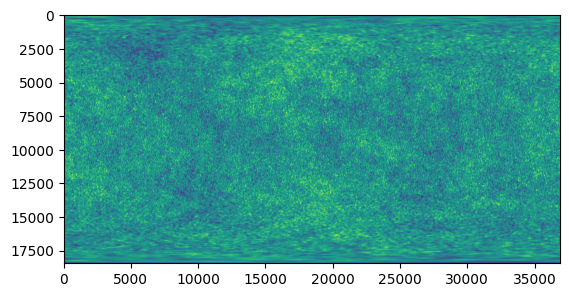

In [ ]:
for i, p, _ in random_indices:
    print(maps.shape)
    plt.imshow(maps[i])

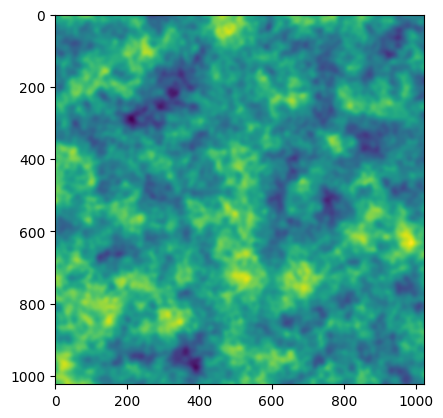

In [ ]:
for i, p, n in random_indices:
    plt.imshow(patches[i, n])

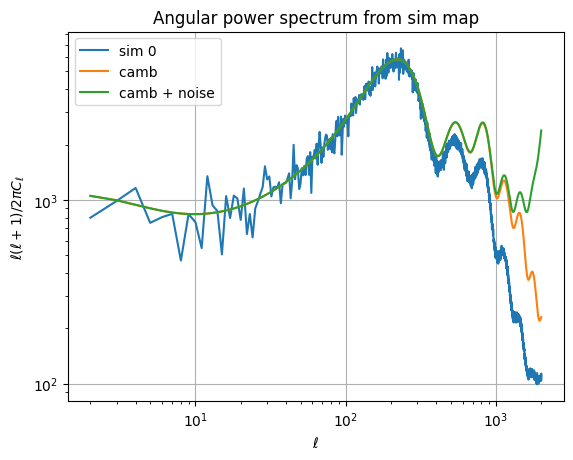

In [ ]:
for i, p, n in random_indices:
    tmap = enmap.ndmap(maps[i], fs_wcs)
    almsd = curvedsky.map2alm(tmap, lmax=lmax)
    cl = curvedsky.alm2cl(almsd)
    # cl = hp.anafast(maps[i, p], lmax=lmax, pol=False, use_pixel_weights=True)
    ell = np.arange(len(cl))

    plt.loglog(ell[2:], (ell * (ell + 1) / 2 / np.pi)[2:] * cl[2:], label=f'sim {0}')

    noise_ell_b = np.array([noise_scales_rad**2 * np.exp( (l*(l+1) * beam_widths_rad**2) / (8*np.log(2)) ) for l in range(nell)])
    camb_cls_n = c_ells['c_ell'][2:lmax] + noise_ell_b[2:lmax, np.newaxis]
    camb_ls = np.arange(2, lmax)

    plt.loglog(camb_ls, camb_ls * (camb_ls + 1) / 2 / np.pi * c_ells['c_ell'][2:lmax][:, 0], label='camb ')
    plt.loglog(camb_ls, camb_ls * (camb_ls + 1) / 2 / np.pi * camb_cls_n[:, 0], label='camb + noise')

    plt.xlabel("$\ell$")
    plt.ylabel("$\ell(\ell+1)/2\pi C_{\ell}$")
    plt.title(f'Angular power spectrum from sim map')
    plt.legend()
    plt.grid()
    plt.show()

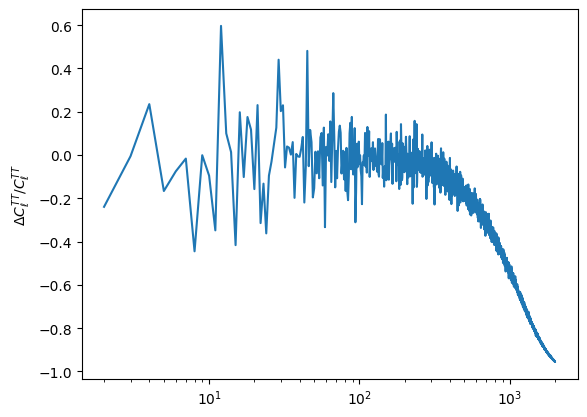

In [ ]:
for i, p, n in random_indices:
    delta_cl = (cl[2:lmax] - camb_cls_n[:, 0]) / camb_cls_n[:, 0]

    plt.semilogx(camb_ls, delta_cl, label='...')
    plt.ylabel('$\Delta C^{TT}_{\ell} / C^{TT}_{\ell}$')
    plt.show()

# Goodbye